# Inspecting the full pipeline for the VAE

In [ ]:
from __future__ import annotations
import numpy as np 
import matplotlib.pyplot as plt
import json
import os
import sys 
import tskit 
from pathlib import Path
import torch

ModuleNotFoundError: No module named 'pytorch_lightning'

In [14]:
PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [15]:
processed_data_path = Path('/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0')

In [16]:
# Let's look at the normalized discovery data
norm_discovery = np.load(f'{processed_data_path}/discovery_train.npy')

In [17]:
norm_discovery.shape

(400, 7127)

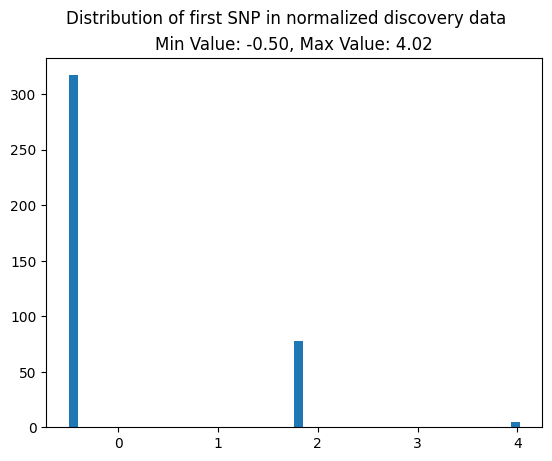

In [18]:
plt.figure()
plt.hist(norm_discovery[:,0], bins=50)
plt.suptitle('Distribution of first SNP in normalized discovery data')
plt.title(f'Min Value: {norm_discovery[:,0].min():.2f}, Max Value: {norm_discovery[:,0].max():.2f}')
plt.show()

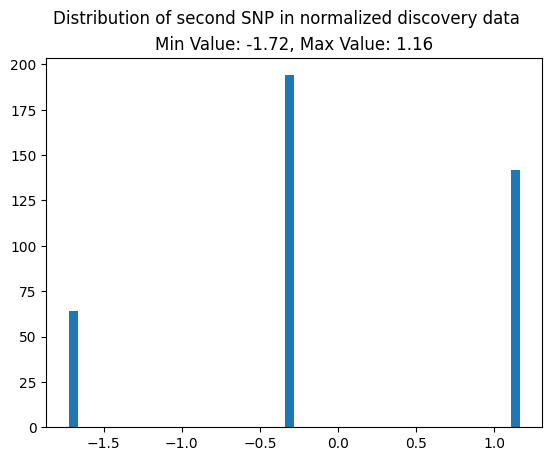

In [19]:
plt.figure()
plt.hist(norm_discovery[:,1], bins=50)
plt.suptitle('Distribution of second SNP in normalized discovery data')
plt.title(f'Min Value: {norm_discovery[:,1].min():.2f}, Max Value: {norm_discovery[:,1].max():.2f}')
plt.show()

In [20]:
print(f'Maximum Value in normalized discovery data: {norm_discovery.max():.2f}')
print(f'Minimum Value in normalized discovery data: {norm_discovery.min():.2f}')

Maximum Value in normalized discovery data: 19.96
Minimum Value in normalized discovery data: -6.42


In [21]:
from src.masking import make_mask_and_apply
x = torch.tensor(norm_discovery[:64], dtype=torch.float32)   # (B, L)

In [42]:
x_in, mask, used_block_len = make_mask_and_apply(
    x,
    enabled=True,
    n_blocks=4,
    block_len=None,       # use mask_frac instead
    mask_frac=0.8,
    allow_overlap=True,
    seed=123,             # deterministic
    fill="gaussian",
    gaussian_std=0.1,
    constant_value=0.0,
)

print(x.shape, x_in.shape, mask.shape, used_block_len)

torch.Size([64, 7127]) torch.Size([64, 7127]) torch.Size([64, 7127]) 1426


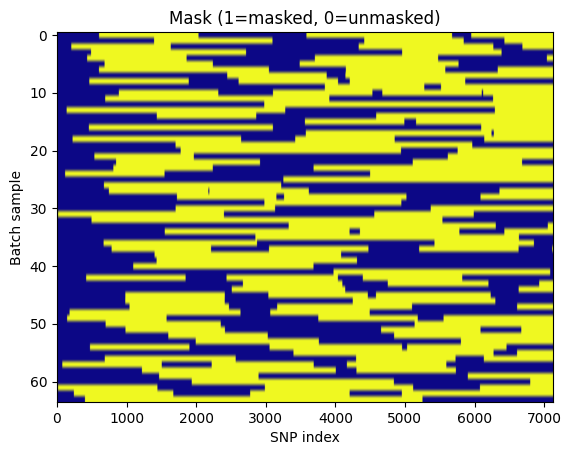

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(mask.cpu().numpy().astype(float), aspect="auto", cmap = "plasma")
plt.title("Mask (1=masked, 0=unmasked)")
plt.xlabel("SNP index")
plt.ylabel("Batch sample")
plt.show()

Shapes: torch.Size([64, 7127]) torch.Size([64, 7127]) torch.Size([64, 7127]) used_block_len: 178


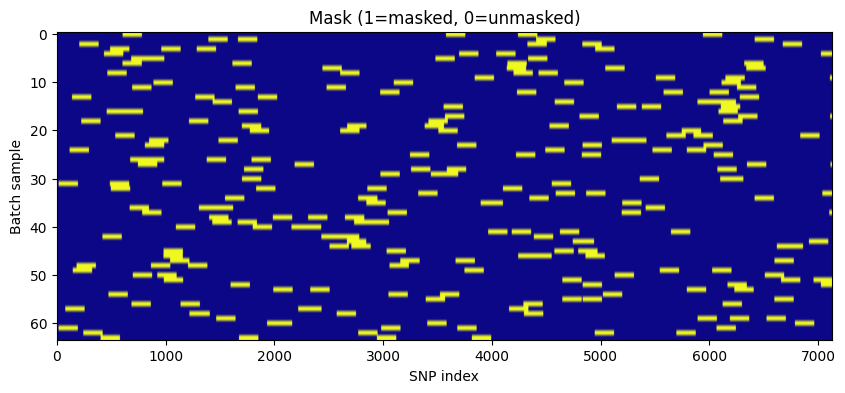

In [45]:
from torch.utils.data import DataLoader, TensorDataset

# --- dataset / loader ---
X = torch.tensor(norm_discovery, dtype=torch.float32)  # (N, L)
ds = TensorDataset(X)
loader = DataLoader(ds, batch_size=64, shuffle=True, num_workers=0, drop_last=True)

batch = next(iter(loader))
x = batch[0]  # (B, L)

# --- apply masking ---
mask_cfg = dict(
    enabled=True,
    n_blocks=4,
    block_len=None,      # use mask_frac instead
    mask_frac=0.1,       # <-- you probably want something like 0.001–0.1 normally; 0.8 is huge but fine for viz
    allow_overlap=True,
    seed=123,
    fill="gaussian",
    gaussian_std=0.1,
    constant_value=0.0,
)

x_in, mask, used_block_len = make_mask_and_apply(x, **mask_cfg)

print("Shapes:", x.shape, x_in.shape, mask.shape, "used_block_len:", used_block_len)

plt.figure(figsize=(10,4))
plt.imshow(mask.numpy().astype(float), aspect="auto", cmap="plasma")
plt.title("Mask (1=masked, 0=unmasked)")
plt.xlabel("SNP index")
plt.ylabel("Batch sample")
plt.show()

In [46]:
from src.vae.model import ConvVAE1D

input_len = norm_discovery.shape[1]

model = ConvVAE1D(
    input_len=input_len,
    latent_dim=64,
    hidden_channels=[64, 128],
    kernel_size=17,
    stride=2,
    padding=8,
    use_batchnorm=False,
)

model.eval()  # we are not training

ConvVAE1D(
  (enc_conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(17,), stride=(2,), padding=(8,))
    (1): ELU(alpha=1.0, inplace=True)
    (2): Conv1d(64, 128, kernel_size=(17,), stride=(2,), padding=(8,))
    (3): ELU(alpha=1.0, inplace=True)
  )
  (fc_mu): Linear(in_features=228096, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=228096, out_features=64, bias=True)
  (fc_dec): Linear(in_features=64, out_features=228096, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose1d(128, 64, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
    (1): ELU(alpha=1.0, inplace=True)
    (2): ConvTranspose1d(64, 1, kernel_size=(17,), stride=(2,), padding=(8,), output_padding=(1,))
  )
)

In [47]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from src.masking import make_mask_and_apply

X = torch.tensor(norm_discovery, dtype=torch.float32)
loader = DataLoader(TensorDataset(X), batch_size=64, shuffle=False)

batch = next(iter(loader))
x = batch[0]   # (B, L)

print("Original x shape:", x.shape)

x_in, mask, used_block_len = make_mask_and_apply(
    x,
    enabled=True,
    n_blocks=4,
    block_len=None,
    mask_frac=0.05,   # use something reasonable
    allow_overlap=True,
    seed=123,
    fill="gaussian",
    gaussian_std=0.1,
    constant_value=0.0,
)

print("Masked x_in shape:", x_in.shape)
print("Mask shape:", mask.shape)

Original x shape: torch.Size([64, 7127])
Masked x_in shape: torch.Size([64, 7127])
Mask shape: torch.Size([64, 7127])


In [48]:
with torch.no_grad():
    recon, mu, logvar = model(x_in)

print("Recon shape:", recon.shape)
print("Mu shape:", mu.shape)
print("Logvar shape:", logvar.shape)

Recon shape: torch.Size([64, 7127])
Mu shape: torch.Size([64, 64])
Logvar shape: torch.Size([64, 64])


/sietch_colab/akapoor/PRS_Portability/src/vae/model.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


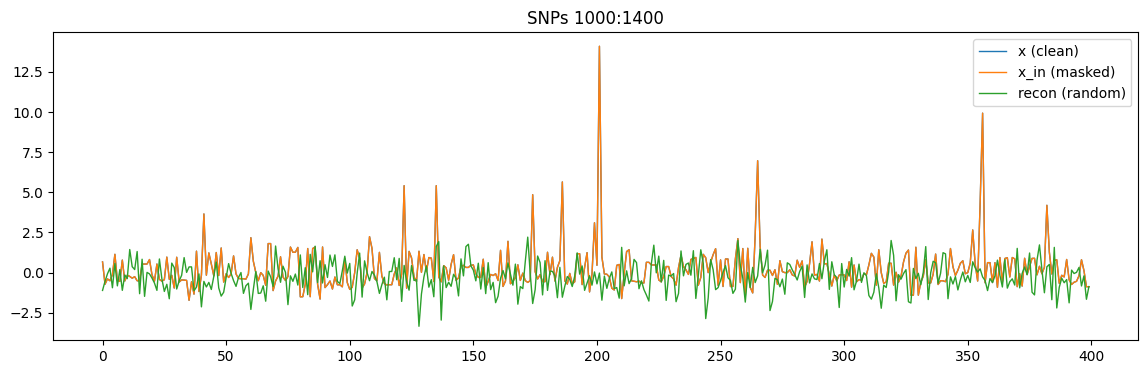

In [55]:
start = 1000
end = 1400   # 400 SNP window

plt.figure(figsize=(14,4))
plt.plot(x_i[start:end], label="x (clean)", linewidth=1)
plt.plot(xin_i[start:end], label="x_in (masked)", linewidth=1)
plt.plot(recon_i[start:end], label="recon (random)", linewidth=1)
plt.legend()
plt.title(f"SNPs {start}:{end}")
plt.show()

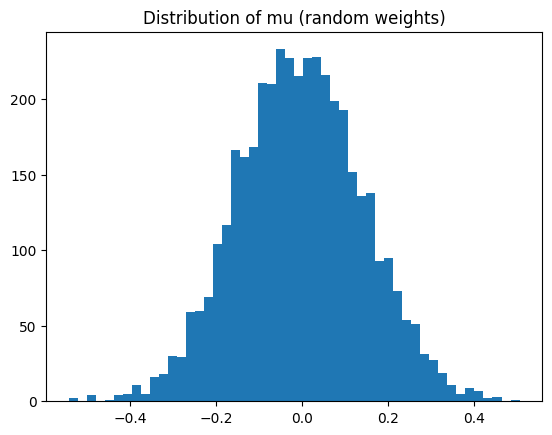

In [50]:
plt.figure()
plt.hist(mu.detach().numpy().flatten(), bins=50)
plt.title("Distribution of mu (random weights)")
plt.show()

In [51]:
print("Input:", x_in.shape)
print("Recon:", recon.shape)
print("Latent mu:", mu.shape)
print("Latent logvar:", logvar.shape)
print("Latent dim:", mu.shape[1])

Input: torch.Size([64, 7127])
Recon: torch.Size([64, 7127])
Latent mu: torch.Size([64, 64])
Latent logvar: torch.Size([64, 64])
Latent dim: 64


## Lightning Model and train_vae

In [60]:
from types import SimpleNamespace
from src.vae.lit_model import LitVAE
import numpy as np, torch

hp = {
  "seed": 0,
  "model": dict(latent_dim=64, hidden_channels=[64,128], kernel_size=17, stride=2, padding=8, use_batchnorm=False),
  "training": dict(lr=3e-4, beta=1e-3, weight_decay=1e-5),
  "masking": dict(enabled=True, alpha_masked=1.0, n_blocks=4, allow_overlap=True,
                  mask_frac=0.001, block_len=None, fill="gaussian", gaussian_std=0.1, constant_value=0.0)
}

# pretend you loaded your npy already:
X = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_train.npy")
input_len = X.shape[1]

cfg = SimpleNamespace(
    input_len=input_len,
    latent_dim=hp["model"]["latent_dim"],
    hidden_channels=tuple(hp["model"]["hidden_channels"]),
    kernel_size=hp["model"]["kernel_size"],
    stride=hp["model"]["stride"],
    padding=hp["model"]["padding"],
    use_batchnorm=hp["model"]["use_batchnorm"],
    seed=hp["seed"],
    training=SimpleNamespace(**hp["training"]),
    masking=SimpleNamespace(**hp["masking"]),
)

lit = LitVAE(cfg)
print("cfg.training.beta =", lit._get_beta() if hasattr(lit, "_get_beta") else "no _get_beta")
print("mask enabled:", getattr(getattr(cfg, "masking", None), "enabled", None))
print("alpha_masked:", getattr(getattr(cfg, "masking", None), "alpha_masked", None))

cfg.training.beta = 0.001
mask enabled: True
alpha_masked: 1.0


In [61]:
x = torch.tensor(X[:64], dtype=torch.float32)
lit.eval()

# If you have _shared_step in LitVAE:
out = lit._shared_step((x,), batch_idx=0, stage="train")

print("Keys:", sorted(out.keys()))
for k in ["loss","recon_objective","kl","mse_masked","mse_unmasked","mse_clean_all","mask_frac","delta_in_l1"]:
    if k in out:
        print(k, float(out[k]))

/sietch_colab/akapoor/PRS_Portability/src/vae/model.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):


Keys: ['delta_in_l1', 'kl', 'kl_clean', 'loss', 'mask_frac', 'mse_clean_all', 'mse_corrupt_all', 'mse_masked', 'mse_unmasked', 'ratio_masked_over_clean', 'recon_objective', 'used_block_len', 'x_in_max', 'x_max']
loss 1.937177062034607
recon_objective 1.9361399412155151
kl 1.0371167659759521
mse_masked 1.9361399412155151
mse_unmasked 1.908164143562317
mse_clean_all 1.9045591354370117
mask_frac 0.0011224918998777866
delta_in_l1 0.0008658605511300266


/tmp/ipykernel_3304887/4050307152.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(k, float(out[k]))


In [62]:
from copy import deepcopy

cfg2 = deepcopy(cfg)

# alpha = 1.0 (pure inpainting)
cfg2.masking.alpha_masked = 1.0
lit1 = LitVAE(cfg2).eval()
o1 = lit1._shared_step((x,), batch_idx=0, stage="train")

# alpha = 0.0 (only unmasked loss)
cfg2.masking.alpha_masked = 0.0
lit0 = LitVAE(cfg2).eval()
o0 = lit0._shared_step((x,), batch_idx=0, stage="train")

print("alpha=1 recon_objective:", float(o1["recon_objective"]), "mse_masked:", float(o1["mse_masked"]))
print("alpha=0 recon_objective:", float(o0["recon_objective"]), "mse_unmasked:", float(o0["mse_unmasked"]))

alpha=1 recon_objective: 2.260103464126587 mse_masked: 2.260103464126587
alpha=0 recon_objective: 2.011857032775879 mse_unmasked: 2.011857032775879


## Trained model results

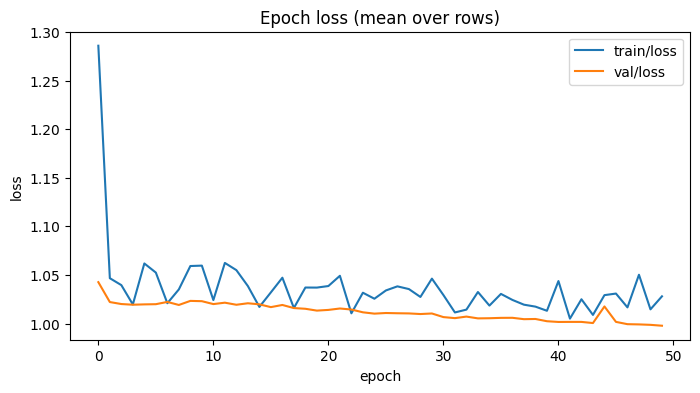

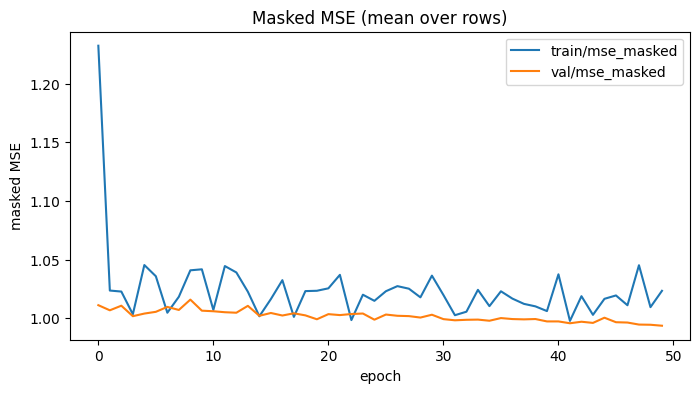

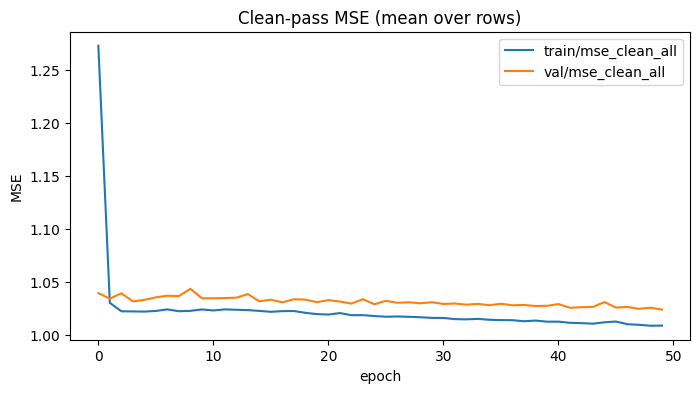

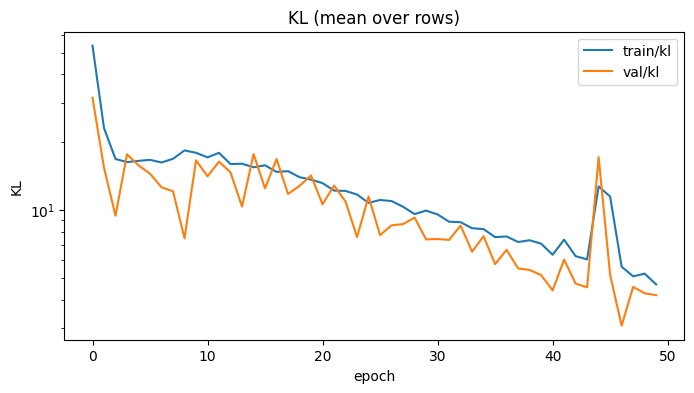

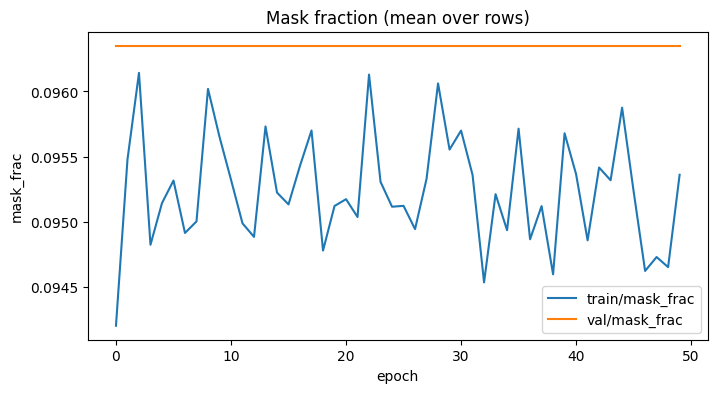

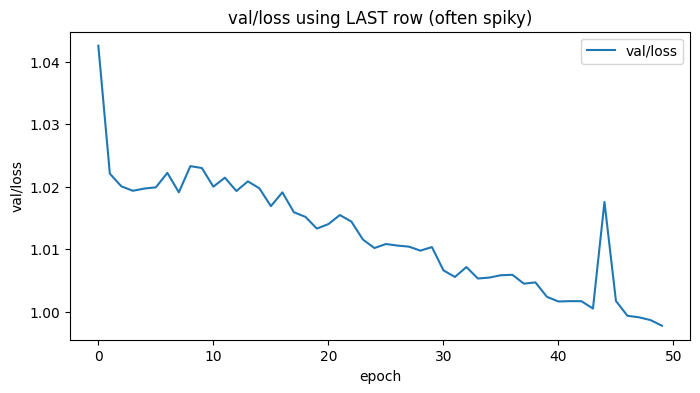

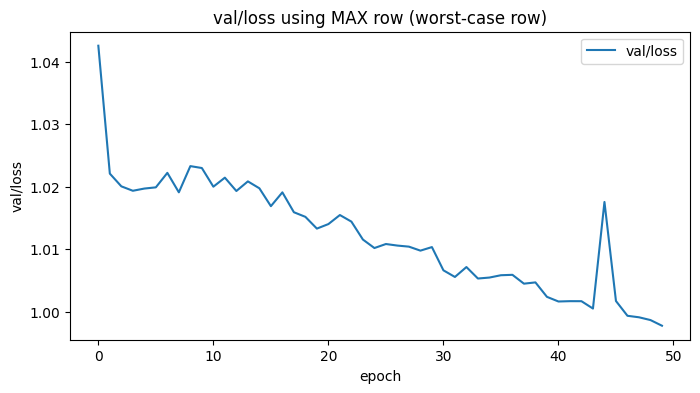

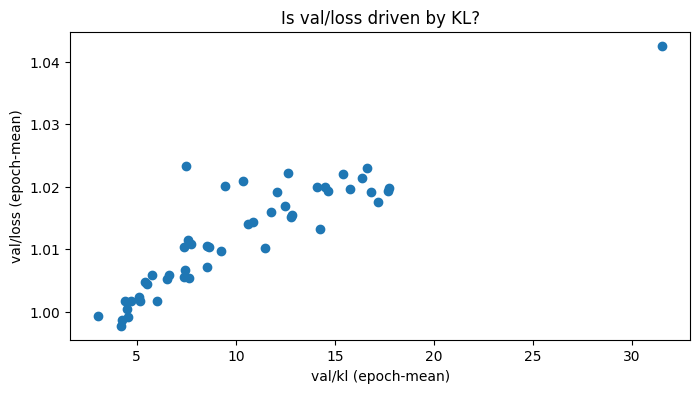

In [97]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

metrics_path = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/vae/default/0/rep0/logs/version_0/metrics.csv")
df = pd.read_csv(metrics_path)

# -----------------------------
# Helpers: robust epoch aggregation
# -----------------------------
def epoch_agg(cols, how="mean"):
    """
    Aggregate metrics across all rows within each epoch.

    how:
      - "mean": average across all rows where metric is present
      - "median": robust to outliers
      - "max": useful diagnostic (shows worst batch/row)
      - "last": what you were doing before (often misleading)
    """
    cols = [c for c in cols if c in df.columns]
    d = df[["epoch"] + cols].copy()
    d = d.dropna(subset=cols, how="all")

    g = d.groupby("epoch", as_index=False)

    if how == "mean":
        out = g[cols].mean(numeric_only=True)
    elif how == "median":
        out = g[cols].median(numeric_only=True)
    elif how == "max":
        out = g[cols].max(numeric_only=True)
    elif how == "last":
        out = g.last()
        # groupby.last keeps epoch as index sometimes; normalize:
        out = out.reset_index()[["epoch"] + cols]
    else:
        raise ValueError("how must be one of: mean|median|max|last")

    return out.sort_values("epoch").reset_index(drop=True)

def plot_epoch(E, y1, y2=None, title=None, ylabel=None, logy=False):
    plt.figure(figsize=(8,4))
    plt.plot(E["epoch"], E[y1], label=y1)
    if y2 is not None and y2 in E.columns:
        plt.plot(E["epoch"], E[y2], label=y2)
    if logy:
        plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel(ylabel if ylabel else y1)
    plt.title(title if title else f"{y1}" + (f" vs {y2}" if y2 else ""))
    plt.legend()
    plt.show()

# -----------------------------
# Choose metrics to inspect
# -----------------------------
cols = [
    "train/loss", "val/loss",
    "train/mse_masked", "val/mse_masked",
    "train/mse_clean_all", "val/mse_clean_all",
    "train/kl", "val/kl",
    "train/mask_frac", "val/mask_frac",
]

E_mean   = epoch_agg(cols, how="mean")
E_median = epoch_agg(cols, how="median")   # optional
E_max    = epoch_agg(cols, how="max")      # diagnostic: worst row per epoch
E_last   = epoch_agg(cols, how="last")     # what you were doing

# -----------------------------
# Core plots (use MEAN as default)
# -----------------------------
plot_epoch(E_mean, "train/loss", "val/loss", title="Epoch loss (mean over rows)", ylabel="loss")
plot_epoch(E_mean, "train/mse_masked", "val/mse_masked", title="Masked MSE (mean over rows)", ylabel="masked MSE")
plot_epoch(E_mean, "train/mse_clean_all", "val/mse_clean_all", title="Clean-pass MSE (mean over rows)", ylabel="MSE")
plot_epoch(E_mean, "train/kl", "val/kl", title="KL (mean over rows)", ylabel="KL", logy=True)
plot_epoch(E_mean, "train/mask_frac", "val/mask_frac", title="Mask fraction (mean over rows)", ylabel="mask_frac")

# -----------------------------
# Diagnostics: are spikes coming from single rows?
# -----------------------------
plot_epoch(E_last, "val/loss", None, title="val/loss using LAST row (often spiky)", ylabel="val/loss")
plot_epoch(E_max,  "val/loss", None, title="val/loss using MAX row (worst-case row)", ylabel="val/loss")

# If E_mean looks smooth but E_last is spiky -> your plotting aggregation was the problem.
# If E_mean is still spiky, check whether KL drives it:
plt.figure(figsize=(8,4))
plt.scatter(E_mean["val/kl"], E_mean["val/loss"])
plt.xlabel("val/kl (epoch-mean)")
plt.ylabel("val/loss (epoch-mean)")
plt.title("Is val/loss driven by KL?")
plt.show()

In [91]:
# x, mask should already exist from earlier
# x: (B, L)
# mask: (B, L) boolean

masked_values = x[mask]          # true masked positions
baseline_mse = (masked_values ** 2).mean().item()

print("Baseline masked MSE (predict 0):", baseline_mse)

Baseline masked MSE (predict 0): 0.9648948311805725


In [92]:
import numpy as np
Xt = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_train.npy")
Xv = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy")

print("train: min/max/mean/std", Xt.min(), Xt.max(), Xt.mean(), Xt.std())
print("val:   min/max/mean/std", Xv.min(), Xv.max(), Xv.mean(), Xv.std())
print("train finite?", np.isfinite(Xt).all(), "val finite?", np.isfinite(Xv).all())

train: min/max/mean/std -6.422054 19.958485 0.0 0.99330837
val:   min/max/mean/std -5.7255836 999.99994 0.0058260853 2.5720177
train finite? True val finite? True


In [93]:
import numpy as np

Xv = np.load("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0/discovery_val.npy")

print("Number of values > 100:", np.sum(Xv > 100))
print("Unique large values:", np.unique(Xv[Xv > 100])[:10])

# Find rows containing them
rows = np.where(np.any(Xv > 100, axis=1))[0]
print("Rows with 999-like values:", rows[:20])

Number of values > 100: 4
Unique large values: [999.99994]
Rows with 999-like values: [49 53]


In [95]:
from pathlib import Path
import numpy as np

outdir = Path("/sietch_colab/akapoor/PRS_Portability/experiments/IM_symmetric/processed_data/0/rep0")

Xv = np.load(outdir / "discovery_val.npy")
rows, cols = np.where(Xv > 100)

print("rows:", np.unique(rows))
print("cols:", np.unique(cols))
print("values:", Xv[rows, cols])

site_ids = np.load(outdir / "variant_site_ids.npy")
pos_bp   = np.load(outdir / "variant_positions_bp.npy")

for c in np.unique(cols):
    print(f"col {c}: site_id={int(site_ids[c])}, pos_bp={float(pos_bp[c])}")

rows: [49 53]
cols: [3960 4022 7100 7108]
values: [999.99994 999.99994 999.99994 999.99994]
col 3960: site_id=38562, pos_bp=5523476.0
col 4022: site_id=39104, pos_bp=5602420.0
col 7100: site_id=69229, pos_bp=9930908.0
col 7108: site_id=69390, pos_bp=9955724.0


In [96]:
Xt = np.load(outdir / "discovery_train.npy")
# Reconstruct the *train* mean/scale used (already saved)
mean  = np.load(outdir / "norm_mean.npy")
scale = np.load(outdir / "norm_scale.npy")

for c in np.unique(cols):
    print("col", c, "scale", float(scale[c]), "mean", float(mean[c]),
          "train unique:", np.unique(((Xt[:, c] * scale[c]) + mean[c]).round(3)))

col 3960 scale 0.0010000000474974513 mean 0.0 train unique: [0.]
col 4022 scale 0.0010000000474974513 mean 0.0 train unique: [0.]
col 7100 scale 0.0010000000474974513 mean 0.0 train unique: [0.]
col 7108 scale 0.0010000000474974513 mean 0.0 train unique: [0.]
